# Part 4: Physics-Informed Machine Learning with ANDES

This notebook demonstrates the automatic symbolic-to-PyTorch pipeline
enabled by ANDES. The GENCLS DAE equations are extracted via
`gen.prepare()`, algebraic variables eliminated with `sp.solve`, and
both first-order ODEs converted to differentiable PyTorch functions
via `sp.lambdify`. The auto-derived residuals are then used as the
physics loss in a parameterized PINN that predicts both $\delta$ and
$\omega$. No physics is hand-coded in PyTorch.

## Setup

The following cell clones the tutorial repository and installs
dependencies when running on Google Colab. On a local machine,
this step is skipped automatically.

In [ ]:
import os

if os.getenv("COLAB_RELEASE_TAG"):
    if not os.path.isdir("gridfm-tutorial"):
        !git clone https://github.com/PowerCyberLab/gridfm-tutorial.git
    %cd gridfm-tutorial
    %pip install -q andes

%matplotlib inline

import time

import numpy as np
import sympy as sp
import torch
import torch.nn as nn
from matplotlib import pyplot as plt

import andes

andes.config_logger(stream_level=40)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.float64

# SymPy-to-PyTorch mapping for sp.lambdify
TORCH_FUNCS = {
    'sin': torch.sin, 'cos': torch.cos, 'exp': torch.exp,
    'log': torch.log, 'sqrt': torch.sqrt, 'Abs': torch.abs,
    'sign': torch.sign, 'asin': torch.asin, 'acos': torch.acos,
    'atan': torch.atan,
    'pi': torch.tensor(np.pi, dtype=torch.float64),
    're': lambda x: x,
    'im': lambda x: torch.zeros_like(x),
}

print(f'Device: {DEVICE}')

## Part A: Symbolic Equation Extraction and Algebraic Elimination

Each variable in an ANDES model carries an `e_str` attribute containing
its residual equation. Calling `model.prepare()` parses these strings
into SymPy expressions stored in `syms.f_list` (differential) and
`syms.g_list` (algebraic).

The 12 internal algebraic equations of GENCLS (currents, voltages,
fluxes, torques) are eliminated automatically with `sp.solve`, leaving
two first-order ODEs in $(\delta, \omega)$ that are converted directly
to differentiable PyTorch functions via `sp.lambdify`.

In [2]:
# Build a minimal Single Machine Infinite Bus (SMIB) system
ss = andes.System(default_config=True)
ss.undill()

ss.add('Bus', idx=1, name='Gen Bus', Vn=20.0, v0=1.0)
ss.add('Bus', idx=2, name='Inf Bus', Vn=20.0, v0=1.0)
ss.add('Line', idx=1, bus1=1, bus2=2, Vn1=20.0, Vn2=20.0,
       r=0.0, x=0.3, b=0.0)
ss.add('PV', idx=1, bus=1, Vn=20.0, p0=0.5, q0=0.0, v0=1.0)
ss.add('Slack', idx=2, bus=2, Vn=20.0, v0=1.0)
ss.add('GENCLS', idx=1, bus=1, gen=1, Sn=100, Vn=20.0,
       M=6.0, D=20.0, xd1=0.3, ra=0.0)

ss.setup()
ss.PFlow.run()
ss.TDS.init()  # populates ConstService values (vf0, tm0, ...)

gen = ss.GENCLS
gen.prepare()  # regenerate symbolic SymPy equations

state_names = list(gen.cache.states_and_ext.keys())
algeb_names = list(gen.cache.algebs_and_ext.keys())

print('GENCLS State Equations (gen.syms.f_list)')
print('=' * 55)
for i, name in enumerate(state_names):
    var = gen.cache.states_and_ext[name]
    tc = f' / {var.t_const.name}' if getattr(var, 't_const', None) else ''
    print(f'  d({name})/dt{tc} = {gen.syms.f_list[i]}')

print(f'\nGENCLS Algebraic Equations (first 6 of {len(algeb_names)})')
print('=' * 55)
for i in range(min(6, len(algeb_names))):
    print(f'  0 = {gen.syms.g_list[i]}')

GENCLS State Equations (gen.syms.f_list)
  d(delta)/dt = 2*pi*fn*ue*(omega - 1)
  d(omega)/dt / M = ue*(-D*(omega - 1) - te + tm)

GENCLS Algebraic Equations (first 6 of 14)
  0 = Id*xq + psid - vf
  0 = Iq*xq + psiq
  0 = -ue*v*sin(a - delta) - vd
  0 = ue*v*cos(a - delta) - vq
  0 = -tm + tm0
  0 = -te + ue*(-Id*psiq + Iq*psid)


In [3]:
# ── Automatic algebraic elimination ──
syms_d = gen.syms.inputs_dict

int_algeb = [n for n, v in gen.cache.algebs_and_ext.items()
             if not hasattr(v, 'model')]
g_eqs = [gen.syms.g_list[i] for i, n in enumerate(algeb_names)
         if n in int_algeb]
g_vars = [syms_d[n] for n in int_algeb]

sol = sp.solve(g_eqs, g_vars, dict=True)[0]
print(f'Eliminated {len(sol)} algebraic variables via sp.solve')

# Substitute into both differential equations
f_delta_reduced = sp.simplify(gen.syms.f_list[0].subs(sol))
f_omega_reduced = sp.simplify(gen.syms.f_list[1].subs(sol))
print(f'\n  d(delta)/dt     = {f_delta_reduced}')
print(f'  M * d(omega)/dt = {f_omega_reduced}')

# ── Fix machine constants; keep per-equilibrium values symbolic ──
const_subs = {syms_d['M']: float(gen.M.v[0]),
              syms_d['D']: float(gen.D.v[0]),
              syms_d['fn']: float(ss.config.freq),
              syms_d['ue']: 1.0, syms_d['ra']: 0.0,
              syms_d['xq']: float(gen.xd1.v[0])}

f_delta_num = sp.simplify(f_delta_reduced.subs(const_subs))
f_omega_num = sp.simplify(f_omega_reduced.subs(const_subs))
M_val = float(gen.M.v[0])

print(f'\nAfter substitution:')
print(f'  d(delta)/dt = {f_delta_num}')
print(f'  d(omega)/dt = ({f_omega_num}) / {M_val}')

# ── Lambdify both ODEs to PyTorch ──
delta_s, omega_s = syms_d['delta'], syms_d['omega']
vf0_s, v_s, a_s, tm0_s = syms_d['vf0'], syms_d['v'], syms_d['a'], syms_d['tm0']
args = [delta_s, omega_s, vf0_s, v_s, a_s, tm0_s]

f_delta_torch = sp.lambdify(args, f_delta_num, modules=[TORCH_FUNCS, 'numpy'])
f_omega_torch = sp.lambdify(args, f_omega_num, modules=[TORCH_FUNCS, 'numpy'])

# Verify autograd
d_test = torch.tensor(0.3, dtype=DTYPE, requires_grad=True)
o_test = torch.tensor(1.0, dtype=DTYPE, requires_grad=True)
ro = f_omega_torch(d_test, o_test,
                   torch.tensor(float(gen.vf0.v[0]), dtype=DTYPE),
                   torch.tensor(float(ss.Bus.v.v[0]), dtype=DTYPE),
                   torch.tensor(float(ss.Bus.a.v[0]), dtype=DTYPE),
                   torch.tensor(float(gen.tm0.v[0]), dtype=DTYPE))
ro.backward()
print(f'\nAutograd OK: d(f_omega)/d(delta) = {d_test.grad.item():.4f}')

Eliminated 12 algebraic variables via sp.solve

  d(delta)/dt     = 2*pi*fn*ue*(omega - 1)
  M * d(omega)/dt = ue*(ue**4*vf0*(ra*ue*v*cos(a - delta) - ra*vf0 + v*xq*sin(a - delta)) - (D*(omega - 1) - tm0)*(ra**2*ue**2 + xq**2))/(ra**2*ue**2 + xq**2)



After substitution:
  d(delta)/dt = 120.0*pi*(omega - 1)
  d(omega)/dt = (-20.0*omega + 1.0*tm0 + 3.33333333333333*v*vf0*sin(a - delta) + 20.0) / 6.0

Autograd OK: d(f_omega)/d(delta) = -3.3699


## Part B: Parameterized PINN with Auto-Derived Physics

The PINN learns the solution surface $(\delta, \omega)(P_m, t)$ across
a range of mechanical power setpoints. ANDES TDS generates the ground
truth; the auto-derived first-order ODE residuals from Part A provide
the physics loss.

For each $P_m$, the per-equilibrium coefficients ($v_{f0}$, $v$, $a$,
$\tau_{m0}$) are extracted from the ANDES solution and interpolated
to each collocation point.

In [4]:
def build_smib(Pm, tf=2.0):
    """Build SMIB, apply 3-cycle fault, run TDS."""
    ss_r = andes.System(default_config=True)
    ss_r.undill()
    ss_r.add('Bus', idx=1, name='Gen', Vn=20.0, v0=1.0)
    ss_r.add('Bus', idx=2, name='Inf', Vn=20.0, v0=1.0)
    ss_r.add('Line', idx=1, bus1=1, bus2=2,
             Vn1=20.0, Vn2=20.0, r=0.0, x=0.3, b=0.0)
    ss_r.add('PV', idx=1, bus=1, Vn=20.0, p0=Pm, q0=0.0, v0=1.0)
    ss_r.add('Slack', idx=2, bus=2, Vn=20.0, v0=1.0)
    ss_r.add('GENCLS', idx=1, bus=1, gen=1, Sn=100, Vn=20.0,
             M=6.0, D=20.0, xd1=0.3, ra=0.0)
    ss_r.add('Fault', idx=1, bus=1, tf=0.1, tc=0.15, xf=1e-4)
    ss_r.setup()
    if not ss_r.PFlow.run():
        return None
    ss_r.TDS.config.tf = tf
    ss_r.TDS.run()
    ts_d = ss_r.TDS.get_timeseries(ss_r.GENCLS.delta)
    ts_o = ss_r.TDS.get_timeseries(ss_r.GENCLS.omega)
    if ts_d is None or len(ts_d) < 20:
        return None
    g = ss_r.GENCLS
    return dict(
        t=ts_d.index.values.astype(np.float64),
        delta=ts_d.iloc[:, 0].values.astype(np.float64),
        omega=ts_o.iloc[:, 0].values.astype(np.float64),
        coeff=dict(vf0=float(g.vf0.v[0]), v=float(ss_r.Bus.v.v[0]),
                   a=float(ss_r.Bus.a.v[0]), tm0=float(g.tm0.v[0])),
    )

In [5]:
Pm_sweep = np.linspace(0.1, 1.2, 20)
tf = 2.0
n_t = 400

print(f'Sweeping {len(Pm_sweep)} Pm values (tf={tf}s, fault at t=0.1s)...')
t0 = time.time()

runs, valid_Pm = [], []
coeffs = {'vf0': [], 'v': [], 'a': [], 'tm0': []}

for Pm in Pm_sweep:
    ret = build_smib(Pm, tf=tf)
    if ret is None:
        continue
    runs.append((ret['t'], ret['delta'], ret['omega']))
    valid_Pm.append(Pm)
    for k in coeffs:
        coeffs[k].append(ret['coeff'][k])

t_vec = np.linspace(0.0, tf, n_t)
usol_delta = np.array([np.interp(t_vec, ti, di) for ti, di, _ in runs])
usol_omega = np.array([np.interp(t_vec, ti, oi) for ti, _, oi in runs])
Pm_vec = np.array(valid_Pm)
for k in coeffs:
    coeffs[k] = np.array(coeffs[k])

print(f'{usol_delta.shape[0]} operating points x {usol_delta.shape[1]} '
      f'time steps, {time.time()-t0:.1f}s')

Sweeping 20 Pm values (tf=2.0s, fault at t=0.1s)...


20 operating points x 400 time steps, 2.9s


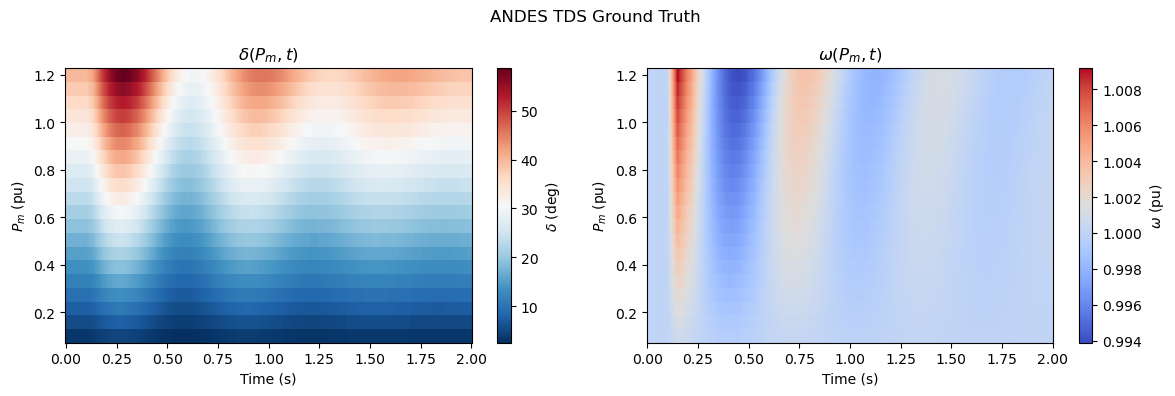

In [6]:
Pm_g, T_g = np.meshgrid(Pm_vec, t_vec, indexing='ij')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
c0 = axes[0].pcolormesh(T_g, Pm_g, np.rad2deg(usol_delta),
                         shading='auto', cmap='RdBu_r')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('$P_m$ (pu)')
axes[0].set_title('$\\delta(P_m, t)$')
fig.colorbar(c0, ax=axes[0], label='$\\delta$ (deg)')

c1 = axes[1].pcolormesh(T_g, Pm_g, usol_omega,
                         shading='auto', cmap='coolwarm')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('$P_m$ (pu)')
axes[1].set_title('$\\omega(P_m, t)$')
fig.colorbar(c1, ax=axes[1], label='$\\omega$ (pu)')

fig.suptitle('ANDES TDS Ground Truth', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
class SurrogateNet(nn.Module):
    """(Pm, t) -> (delta, omega) with input/output normalization."""

    def __init__(self, widths, lb, ub, y_shift, y_scale):
        super().__init__()
        self.register_buffer('lb', torch.tensor(lb, dtype=DTYPE))
        self.register_buffer('ub', torch.tensor(ub, dtype=DTYPE))
        self.register_buffer('y_shift', torch.tensor(y_shift, dtype=DTYPE))
        self.register_buffer('y_scale', torch.tensor(y_scale, dtype=DTYPE))

        layers = []
        for i in range(len(widths) - 1):
            layers.append(nn.Linear(widths[i], widths[i + 1]))
            if i < len(widths) - 2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, X):
        H = 2.0 * (X - self.lb) / (self.ub - self.lb + 1e-12) - 1.0
        return self.net(H) * self.y_scale + self.y_shift


np.random.seed(42)
torch.manual_seed(42)

X_all = np.column_stack([Pm_g.ravel(), T_g.ravel()])
u_delta = usol_delta.ravel()
u_omega = usol_omega.ravel()

X_u = torch.tensor(X_all, dtype=DTYPE, device=DEVICE)
y_u = torch.tensor(np.column_stack([u_delta, u_omega]),
                    dtype=DTYPE, device=DEVICE)

lb = np.array([Pm_vec[0], t_vec[0]])
ub = np.array([Pm_vec[-1], t_vec[-1]])

# Collocation points (exclude fault window 0.1-0.15s)
N_coll = 8000
pts = lb + (ub - lb) * np.random.rand(2 * N_coll, 2)
mask = (pts[:, 1] < 0.1) | (pts[:, 1] > 0.15)
pts = pts[mask][:N_coll]
X_f = torch.tensor(pts, dtype=DTYPE, device=DEVICE)

Pm_coll = X_f[:, 0].cpu().numpy()
coll_coeffs = {}
for k in coeffs:
    coll_coeffs[k] = torch.tensor(
        np.interp(Pm_coll, Pm_vec, coeffs[k]),
        dtype=DTYPE, device=DEVICE).unsqueeze(1)

y_mean = np.array([u_delta.mean(), u_omega.mean()])
y_std = np.array([max(u_delta.std(), 1e-6), max(u_omega.std(), 1e-6)])
widths = [2, 256, 256, 256, 2]

model = SurrogateNet(widths, lb, ub,
                     y_shift=y_mean, y_scale=y_std).to(DEVICE).to(DTYPE)

print(f'Network: {widths}')
print(f'Supervised: {X_u.shape[0]}, Collocation: {X_f.shape[0]}')

Network: [2, 256, 256, 256, 2]
Supervised: 8000, Collocation: 8000


In [8]:
def compute_physics_loss(model, X_f, coll_coeffs, M_val):
    """Physics loss enforcing both first-order ODEs."""
    X = X_f.clone().requires_grad_(True)
    out = model(X)
    delta_pred, omega_pred = out[:, 0:1], out[:, 1:2]

    ones = torch.ones_like(delta_pred)
    ddelta_dt = torch.autograd.grad(delta_pred, X, ones, create_graph=True)[0][:, 1:2]
    domega_dt = torch.autograd.grad(omega_pred, X, ones, create_graph=True)[0][:, 1:2]

    rhs_delta = f_delta_torch(delta_pred, omega_pred,
                              coll_coeffs['vf0'], coll_coeffs['v'],
                              coll_coeffs['a'], coll_coeffs['tm0'])
    rhs_omega = f_omega_torch(delta_pred, omega_pred,
                              coll_coeffs['vf0'], coll_coeffs['v'],
                              coll_coeffs['a'], coll_coeffs['tm0']) / M_val

    return torch.mean((ddelta_dt - rhs_delta)**2) + torch.mean((domega_dt - rhs_omega)**2)


PHYS_WEIGHT = 0.01
ADAM_EPOCHS = 5000
hist = {'total': [], 'data': [], 'phys': []}
t0 = time.time()

# ── Adam phase ──
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt, T_max=ADAM_EPOCHS, eta_min=1e-5)

for ep in range(1, ADAM_EPOCHS + 1):
    opt.zero_grad()
    ld = torch.mean((model(X_u) - y_u) ** 2)
    lp = compute_physics_loss(model, X_f, coll_coeffs, M_val)
    loss = ld + PHYS_WEIGHT * lp
    loss.backward()
    opt.step()
    sched.step()
    hist['total'].append(loss.item())
    hist['data'].append(ld.item())
    hist['phys'].append(lp.item())

print(f'Adam {ADAM_EPOCHS} epochs:  data={ld.item():.2e}  phys={lp.item():.2e}')

# ── L-BFGS refinement ──
lbfgs = torch.optim.LBFGS(
    model.parameters(), max_iter=1000, max_eval=1250,
    tolerance_grad=1e-9, tolerance_change=1e-11,
    history_size=100, line_search_fn='strong_wolfe')

lbfgs_it = [0]
def closure():
    lbfgs.zero_grad()
    ld = torch.mean((model(X_u) - y_u) ** 2)
    lp = compute_physics_loss(model, X_f, coll_coeffs, M_val)
    loss = ld + PHYS_WEIGHT * lp
    loss.backward()
    lbfgs_it[0] += 1
    hist['total'].append(loss.item())
    hist['data'].append(ld.item())
    hist['phys'].append(lp.item())
    return loss

lbfgs.step(closure)

ld_f = torch.mean((model(X_u) - y_u) ** 2)
lp_f = compute_physics_loss(model, X_f, coll_coeffs, M_val)
print(f'L-BFGS {lbfgs_it[0]} iters: data={ld_f.item():.2e}  phys={lp_f.item():.2e}')
print(f'Total: {time.time()-t0:.1f}s')

Adam 5000 epochs:  data=1.32e-05  phys=9.04e-04


L-BFGS 1030 iters: data=4.94e-07  phys=6.48e-04
Total: 261.8s


delta:  MAE = 0.037 deg,  max = 0.456 deg
omega:  MAE = 0.000063 pu,   max = 0.001948 pu


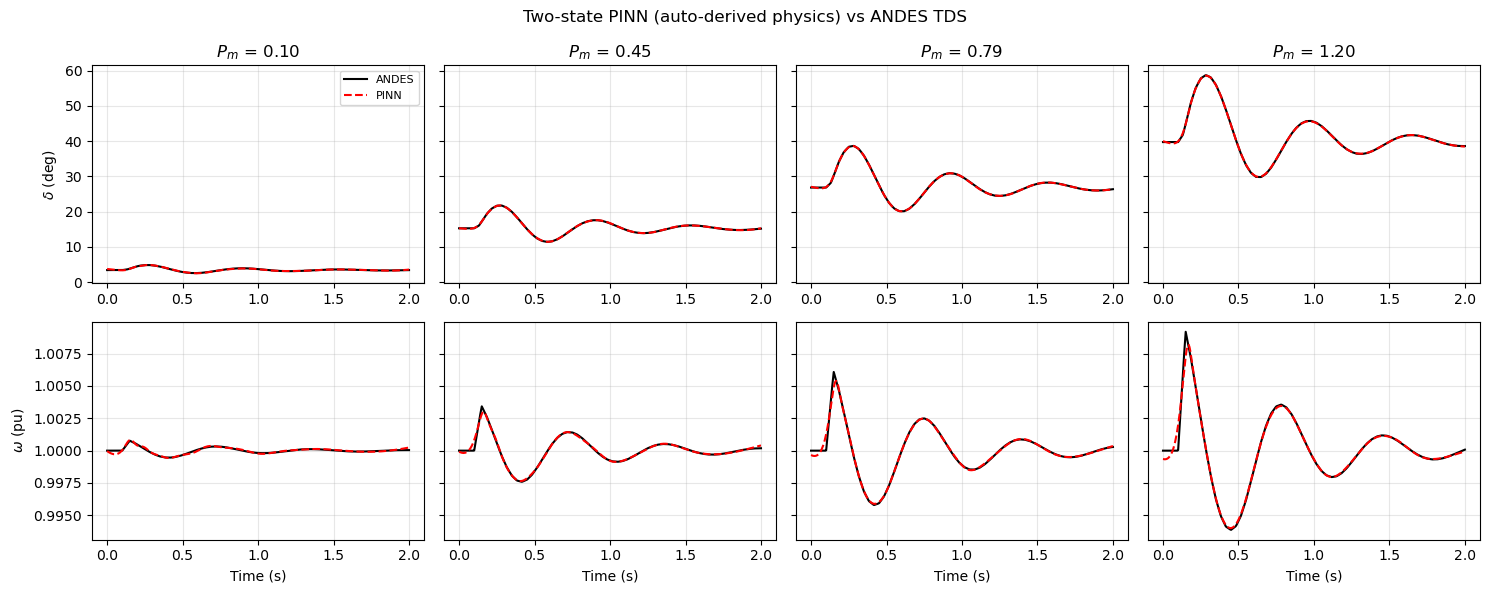

In [9]:
model.eval()

with torch.no_grad():
    X_t = torch.tensor(X_all, dtype=DTYPE, device=DEVICE)
    pred = model(X_t).cpu().numpy().reshape(
        usol_delta.shape[0], usol_delta.shape[1], 2)

pred_delta, pred_omega = pred[:, :, 0], pred[:, :, 1]
err_delta = np.abs(pred_delta - usol_delta)
err_omega = np.abs(pred_omega - usol_omega)

print(f'delta:  MAE = {np.rad2deg(err_delta.mean()):.3f} deg,  '
      f'max = {np.rad2deg(err_delta.max()):.3f} deg')
print(f'omega:  MAE = {err_omega.mean():.6f} pu,   '
      f'max = {err_omega.max():.6f} pu')

# Trajectory slices
slice_idx = np.linspace(0, len(Pm_vec) - 1, 4, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharey='row')
for j, si in enumerate(slice_idx):
    axes[0, j].plot(t_vec, np.rad2deg(usol_delta[si]), 'k-', lw=1.5, label='ANDES')
    axes[0, j].plot(t_vec, np.rad2deg(pred_delta[si]), 'r--', lw=1.5, label='PINN')
    axes[0, j].set_title(f'$P_m$ = {Pm_vec[si]:.2f}')
    axes[0, j].grid(True, alpha=0.3)
    if j == 0:
        axes[0, j].set_ylabel('$\\delta$ (deg)')
        axes[0, j].legend(fontsize=8)

    axes[1, j].plot(t_vec, usol_omega[si], 'k-', lw=1.5)
    axes[1, j].plot(t_vec, pred_omega[si], 'r--', lw=1.5)
    axes[1, j].set_xlabel('Time (s)')
    axes[1, j].grid(True, alpha=0.3)
    if j == 0:
        axes[1, j].set_ylabel('$\\omega$ (pu)')

fig.suptitle('Two-state PINN (auto-derived physics) vs ANDES TDS', fontsize=12)
plt.tight_layout()
plt.show()

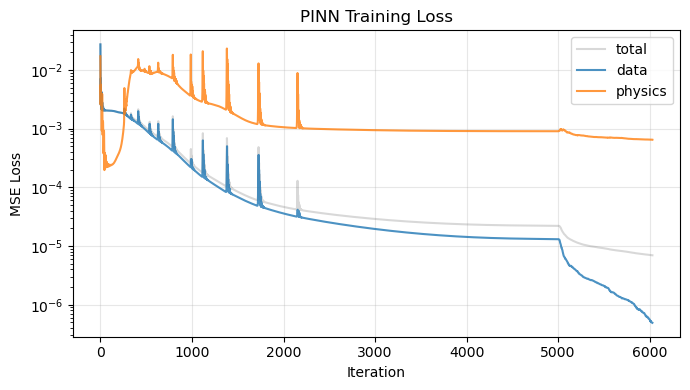

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(hist['total'], alpha=0.3, label='total', color='gray')
ax.semilogy(hist['data'], alpha=0.8, label='data', color='C0')
ax.semilogy(hist['phys'], alpha=0.8, label='physics', color='C1')
ax.set_xlabel('Iteration')
ax.set_ylabel('MSE Loss')
ax.set_title('PINN Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated an automatic symbolic-to-PyTorch pipeline
for physics-informed machine learning. The GENCLS differential and
algebraic equations were extracted via `gen.prepare()`, the 12 internal
algebraic variables eliminated with `sp.solve`, and both first-order
ODEs converted directly to differentiable PyTorch functions via
`sp.lambdify`. No physics was hand-coded in PyTorch. The two-state PINN
trained with these auto-derived residuals achieves sub-degree accuracy
for $\delta$ and sub-0.002 pu accuracy for $\omega$.

For foundation model research, these capabilities position ANDES as both
a **data generator** (trajectory datasets via TDS) and a **physics
oracle** (differentiable residual equations for physics-informed
training).

For an example of reinforcement learning with ANDES, see the
[RL Oscillation Damping on SMIB](https://docs.andes.app/en/stable/gallery/smib-oscillation.html)
notebook in the ANDES gallery, which trains a PPO agent to damp
post-fault rotor oscillations using the Gymnasium-compatible `AndesEnv`.

In [11]:
!andes misc -C

No output file found in the working directory.
